<a href="https://colab.research.google.com/github/Joydas2003/Electrical-Load-Forcasting-Ml/blob/master/Machine%20Learning%20Based%20short%20term%20Electrical%20Load%20Forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')
pgcb_df=pd.read_csv( "/content/drive/MyDrive/Load Forcasting/PGCB_date_power_demand.csv")
nasa_df=pd.read_csv("/content/drive/MyDrive/Load Forcasting/Hourly_Temp_Humidity (2).csv")
from IPython.display import display

display(pgcb_df)
display(nasa_df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks
0,4/19/2015 22:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,4/19/2015 21:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,4/19/2015 19:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,4/19/2015 18:30,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,4/19/2015 18:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92645,6/17/2025 4:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN
92646,6/17/2025 3:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN
92647,6/17/2025 2:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN
92648,6/17/2025 1:00,14093.0,14115,21,6323,1350,4019,172,0.0,28.0,924,38,1201.0,38.0,NaN


,datetime,Temperature_C,Humidity_%
0,2015-01-19 00:00:00,13.79,66.79
1,2015-01-19 01:00:00,13.25,69.37
2,2015-01-19 02:00:00,12.73,72.19
3,2015-01-19 03:00:00,12.21,75.48
4,2015-01-19 04:00:00,11.78,78.84
...,...,...,...
91267,2025-06-17 19:00:00,26.98,95.39
91268,2025-06-17 20:00:00,26.81,96.40
91269,2025-06-17 21:00:00,26.70,96.67
91270,2025-06-17 22:00:00,26.61,96.64


In [3]:
# Date column গুলো ensure করা datetime format এ আছে
pgcb_df['datetime'] = pd.to_datetime(pgcb_df['datetime'])
nasa_df['datetime'] = pd.to_datetime(nasa_df['datetime'])

# Merge করা, left join করলে সব PGCB date থাকবে
df = pd.merge(pgcb_df, nasa_df, on='datetime', how='left')

# Display
from IPython.display import display
display(df)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.48,84.04
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.92,80.84
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN,28.49,70.64
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak,NaN,NaN
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN,29.50,65.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92645,2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN,26.71,95.81
92646,2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN,26.79,95.97
92647,2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN,26.83,96.17
92648,2025-06-17 01:00:00,14093.0,14115,21,6323,1350,4019,172,0.0,28.0,924,38,1201.0,38.0,NaN,26.87,96.23


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   datetime                92650 non-null  datetime64[ns]
 1   generation_mw           92650 non-null  float64       
 2   demand_mw               92650 non-null  int64         
 3   load_shedding           92650 non-null  int64         
 4   gas                     92650 non-null  int64         
 5   liquid_fuel             92650 non-null  int64         
 6   coal                    92650 non-null  int64         
 7   hydro                   92650 non-null  int64         
 8   solar                   70517 non-null  float64       
 9   wind                    18676 non-null  float64       
 10  india_bheramara_hvdc    92650 non-null  int64         
 11  india_bheramara_hvdc.1  92650 non-null  int64         
 12  india_bheramara_hvdc.2  7338 non-null   float6

Convert the column datatype to datetime format.

In [5]:
df["datetime"]=pd.to_datetime(df["datetime"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   datetime                92650 non-null  datetime64[ns]
 1   generation_mw           92650 non-null  float64       
 2   demand_mw               92650 non-null  int64         
 3   load_shedding           92650 non-null  int64         
 4   gas                     92650 non-null  int64         
 5   liquid_fuel             92650 non-null  int64         
 6   coal                    92650 non-null  int64         
 7   hydro                   92650 non-null  int64         
 8   solar                   70517 non-null  float64       
 9   wind                    18676 non-null  float64       
 10  india_bheramara_hvdc    92650 non-null  int64         
 11  india_bheramara_hvdc.1  92650 non-null  int64         
 12  india_bheramara_hvdc.2  7338 non-null   float6

In [6]:
df=df.set_index("datetime")
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.48,84.04
2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.92,80.84
2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN,28.49,70.64
2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak,NaN,NaN
2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN,29.50,65.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN,26.71,95.81
2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN,26.79,95.97
2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN,26.83,96.17


In [7]:
df.index=pd.to_datetime(df.index)
df=df.sort_index()
df = df.loc['2018-07-19':'2025-07-18']
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2018-07-19 00:00:00,10706.0,10706,0,5578,4251,132,160,0.0,NaN,470,121,NaN,NaN,NaN,27.09,96.62
2018-07-19 01:00:00,10385.0,10385,0,5543,3967,130,160,0.0,NaN,470,121,NaN,NaN,NaN,26.95,96.98
2018-07-19 02:00:00,10073.0,10073,0,5567,3634,127,160,0.0,NaN,470,121,NaN,NaN,NaN,26.96,96.52
2018-07-19 03:00:00,9845.0,9845,0,5723,3246,131,161,0.0,NaN,470,120,NaN,NaN,NaN,27.01,95.95
2018-07-19 04:00:00,9950.0,9950,0,5678,3393,138,161,0.0,NaN,470,116,NaN,NaN,NaN,26.89,96.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [8]:
df.describe()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,Temperature_C,Humidity_%
count,6.306500e+04,63065.000000,63065.000000,63065.000000,6.306500e+04,63065.000000,63065.000000,63065.000000,18676.000000,63065.000000,63065.000000,7338.000000,5351.000000,60553.000000,60553.000000
mean,1.072459e+04,9826.617252,117.281234,5451.760438,2.260530e+03,1359.012305,88.297566,51.600225,9.233133,771.012971,106.019979,881.196375,0.546814,25.522209,77.857775
std,2.569189e+05,2662.700204,397.483993,1061.250299,1.163677e+05,1319.801087,68.050372,111.277477,16.272517,367.555231,39.503734,369.905673,4.525897,5.471290,18.433851
min,5.710000e+02,143.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.020000,17.050000
25%,7.978000e+03,7982.000000,0.000000,4816.000000,6.930000e+02,371.000000,40.000000,0.000000,0.000000,693.000000,80.000000,702.000000,0.000000,22.340000,67.000000
50%,9.639700e+03,9675.000000,0.000000,5506.000000,1.579000e+03,700.000000,70.000000,0.000000,4.000000,857.000000,106.000000,822.000000,0.000000,26.710000,82.190000
75%,1.141100e+04,11581.000000,0.000000,6079.000000,2.691000e+03,2328.000000,126.000000,33.000000,13.000000,921.000000,132.000000,1050.750000,0.000000,29.100000,93.860000
max,6.452650e+07,156050.000000,45068.000000,68763.000000,2.922290e+07,31687.000000,4860.000000,2998.000000,922.000000,76292.000000,1565.000000,12665.000000,38.000000,42.700000,100.000000


Check the missing values

In [9]:
df.isnull().sum()

,0
generation_mw,0
demand_mw,0
load_shedding,0
gas,0
liquid_fuel,0
coal,0
hydro,0
solar,0
wind,44389
india_bheramara_hvdc,0


To show the records that contain any null values

In [10]:
df[df.isna().any(axis=1)]

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2018-07-19 00:00:00,10706.0,10706,0,5578,4251,132,160,0.0,NaN,470,121,NaN,NaN,NaN,27.09,96.62
2018-07-19 01:00:00,10385.0,10385,0,5543,3967,130,160,0.0,NaN,470,121,NaN,NaN,NaN,26.95,96.98
2018-07-19 02:00:00,10073.0,10073,0,5567,3634,127,160,0.0,NaN,470,121,NaN,NaN,NaN,26.96,96.52
2018-07-19 03:00:00,9845.0,9845,0,5723,3246,131,161,0.0,NaN,470,120,NaN,NaN,NaN,27.01,95.95
2018-07-19 04:00:00,9950.0,9950,0,5678,3393,138,161,0.0,NaN,470,116,NaN,NaN,NaN,26.89,96.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 07:00:00,11745.0,11745,0,5614,494,3487,132,128.0,28.0,924,26,874.0,38.0,NaN,28.00,91.76
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07


To show the records that contain all null values

In [11]:
df[df.isna().all(axis=1)]

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,


Drop those rows that contain all missing values

In [12]:
df=df.dropna(how="all")
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2018-07-19 00:00:00,10706.0,10706,0,5578,4251,132,160,0.0,NaN,470,121,NaN,NaN,NaN,27.09,96.62
2018-07-19 01:00:00,10385.0,10385,0,5543,3967,130,160,0.0,NaN,470,121,NaN,NaN,NaN,26.95,96.98
2018-07-19 02:00:00,10073.0,10073,0,5567,3634,127,160,0.0,NaN,470,121,NaN,NaN,NaN,26.96,96.52
2018-07-19 03:00:00,9845.0,9845,0,5723,3246,131,161,0.0,NaN,470,120,NaN,NaN,NaN,27.01,95.95
2018-07-19 04:00:00,9950.0,9950,0,5678,3393,138,161,0.0,NaN,470,116,NaN,NaN,NaN,26.89,96.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


Backwaer Fill -bfill

Forward Fill -ffill

In [13]:
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2018-07-19 00:00:00,10706.0,10706,0,5578,4251,132,160,0.0,NaN,470,121,NaN,NaN,NaN,27.09,96.62
2018-07-19 01:00:00,10385.0,10385,0,5543,3967,130,160,0.0,NaN,470,121,NaN,NaN,NaN,26.95,96.98
2018-07-19 02:00:00,10073.0,10073,0,5567,3634,127,160,0.0,NaN,470,121,NaN,NaN,NaN,26.96,96.52
2018-07-19 03:00:00,9845.0,9845,0,5723,3246,131,161,0.0,NaN,470,120,NaN,NaN,NaN,27.01,95.95
2018-07-19 04:00:00,9950.0,9950,0,5678,3393,138,161,0.0,NaN,470,116,NaN,NaN,NaN,26.89,96.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [14]:
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [15]:
df.columns

Index(['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel',
       'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_bheramara_hvdc.1', 'india_bheramara_hvdc.2',
       'india_bheramara_hvdc.3', 'remarks', 'Temperature_C', 'Humidity_%'],
      dtype='object')

In [16]:
cols = [
 'demand_mw', 'generation_mw',
 'gas', 'coal', 'hydro',
 'solar', 'wind', 'liquid_fuel',
 'india_bheramara_hvdc','Temperature_C','Humidity_%'
]
df[cols] = df[cols].interpolate(method='time')
df[cols] = df[cols].ffill().bfill()
df


,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2018-07-19 00:00:00,10706.0,10706,0,5578,4251,132,160,0.0,3.0,470,121,NaN,NaN,NaN,27.09,96.62
2018-07-19 01:00:00,10385.0,10385,0,5543,3967,130,160,0.0,3.0,470,121,NaN,NaN,NaN,26.95,96.98
2018-07-19 02:00:00,10073.0,10073,0,5567,3634,127,160,0.0,3.0,470,121,NaN,NaN,NaN,26.96,96.52
2018-07-19 03:00:00,9845.0,9845,0,5723,3246,131,161,0.0,3.0,470,120,NaN,NaN,NaN,27.01,95.95
2018-07-19 04:00:00,9950.0,9950,0,5678,3393,138,161,0.0,3.0,470,116,NaN,NaN,NaN,26.89,96.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [17]:
df.columns

Index(['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel',
       'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_bheramara_hvdc.1', 'india_bheramara_hvdc.2',
       'india_bheramara_hvdc.3', 'remarks', 'Temperature_C', 'Humidity_%'],
      dtype='object')

In [18]:
df.isna().sum()

,0
generation_mw,0
demand_mw,0
load_shedding,0
gas,0
liquid_fuel,0
coal,0
hydro,0
solar,0
wind,0
india_bheramara_hvdc,0


create the quarter column in the dataset

Feature Engineering

In [19]:
df.insert(0,"hour",df.index.hour)
df.insert(2,'month',df.index.month)
df.insert(3,'year',df.index.year)
df

,hour,generation_mw,month,year,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,,,,
2018-07-19 00:00:00,0,10706.0,7,2018,10706,0,5578,4251,132,160,0.0,3.0,470,121,NaN,NaN,NaN,27.09,96.62
2018-07-19 01:00:00,1,10385.0,7,2018,10385,0,5543,3967,130,160,0.0,3.0,470,121,NaN,NaN,NaN,26.95,96.98
2018-07-19 02:00:00,2,10073.0,7,2018,10073,0,5567,3634,127,160,0.0,3.0,470,121,NaN,NaN,NaN,26.96,96.52
2018-07-19 03:00:00,3,9845.0,7,2018,9845,0,5723,3246,131,161,0.0,3.0,470,120,NaN,NaN,NaN,27.01,95.95
2018-07-19 04:00:00,4,9950.0,7,2018,9950,0,5678,3393,138,161,0.0,3.0,470,116,NaN,NaN,NaN,26.89,96.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,9,12290.0,6,2025,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,10,12443.0,6,2025,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 63065 entries, 2018-07-19 00:00:00 to 2025-06-17 12:00:00
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   hour                    63065 non-null  int32  
 1   generation_mw           63065 non-null  float64
 2   month                   63065 non-null  int32  
 3   year                    63065 non-null  int32  
 4   demand_mw               63065 non-null  int64  
 5   load_shedding           63065 non-null  int64  
 6   gas                     63065 non-null  int64  
 7   liquid_fuel             63065 non-null  int64  
 8   coal                    63065 non-null  int64  
 9   hydro                   63065 non-null  int64  
 10  solar                   63065 non-null  float64
 11  wind                    63065 non-null  float64
 12  india_bheramara_hvdc    63065 non-null  int64  
 13  india_bheramara_hvdc.1  63065 non-null  int64  
 14  ind

Laged Features : These are the past values of a time series data.

Use- past demand values are strong predictors.They can be used as input to predict future values.

In [21]:
#Demand from the same hour yesterday, same hour last week.
df['Demand_lag_24hr']=df["demand_mw"].shift(24)
df['Demand_lag_168hr']=df["demand_mw"].shift(168) #24*7=168 hour for week shift
df

,hour,generation_mw,month,year,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,...,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%,Demand_lag_24hr,Demand_lag_168hr
datetime,,,,,,,,,,,,,,,,,,,,,
2018-07-19 00:00:00,0,10706.0,7,2018,10706,0,5578,4251,132,160,...,3.0,470,121,NaN,NaN,NaN,27.09,96.62,NaN,NaN
2018-07-19 01:00:00,1,10385.0,7,2018,10385,0,5543,3967,130,160,...,3.0,470,121,NaN,NaN,NaN,26.95,96.98,NaN,NaN
2018-07-19 02:00:00,2,10073.0,7,2018,10073,0,5567,3634,127,160,...,3.0,470,121,NaN,NaN,NaN,26.96,96.52,NaN,NaN
2018-07-19 03:00:00,3,9845.0,7,2018,9845,0,5723,3246,131,161,...,3.0,470,120,NaN,NaN,NaN,27.01,95.95,NaN,NaN
2018-07-19 04:00:00,4,9950.0,7,2018,9950,0,5678,3393,138,161,...,3.0,470,116,NaN,NaN,NaN,26.89,96.04,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,11896,0,5678,490,3470,132,...,57.0,924,24,864.0,38.0,NaN,28.74,87.73,13155.0,12403.0
2025-06-17 09:00:00,9,12290.0,6,2025,12290,0,6065,531,3491,132,...,16.0,924,24,866.0,38.0,NaN,29.37,84.07,13569.0,12072.0
2025-06-17 10:00:00,10,12443.0,6,2025,12443,0,5900,552,3601,172,...,31.0,923,26,985.0,38.0,NaN,29.77,81.71,13816.0,11377.0


In [22]:
#Rolling Mean and rolling standard deviation
df["demand_rolling_mean_24hr"]=df["demand_mw"].rolling(window=24).mean()

In [23]:
df["demand_rolling_mean_48hr"] = df["demand_mw"].rolling(window=48).mean()

In [24]:
df["demand_ema_24hr"] = df["demand_mw"].ewm(span=24, adjust=False).mean()

In [25]:
df["temp_rolling_mean_24hr"] = df["Temperature_C"].rolling(24).mean()
df['coal_share'] = df['coal'] / df['generation_mw']

In [26]:
# Non-renewable sources
gas = df['gas'].sum()
liquid_fuel = df['liquid_fuel'].sum()
coal = df['coal'].sum()

# Renewable sources (combine)
renewable = df[['hydro','solar','wind']].sum().sum()

# India import combine
india_import = df[['india_bheramara_hvdc',
                   'india_bheramara_hvdc.1',
                   'india_bheramara_hvdc.2',
                   'india_bheramara_hvdc.3']].sum().sum()

# Create dictionary
energy_sources = {
    'Gas': gas,
    'Liquid Fuel': liquid_fuel,
    'Coal': coal,
    'Renewable (Hydro+Solar+Wind)': renewable,
    'India Import': india_import
}

# Convert to pandas series
source_generation = pd.Series(energy_sources)

# Total generation
total_generation = source_generation.sum()

# Percentage
source_percent = (source_generation / total_generation) * 100

print(source_percent)

Gas                             53.471449
Liquid Fuel                     22.171522
Coal                            13.329338
Renewable (Hydro+Solar+Wind)     1.419552
India Import                     9.608139
dtype: float64


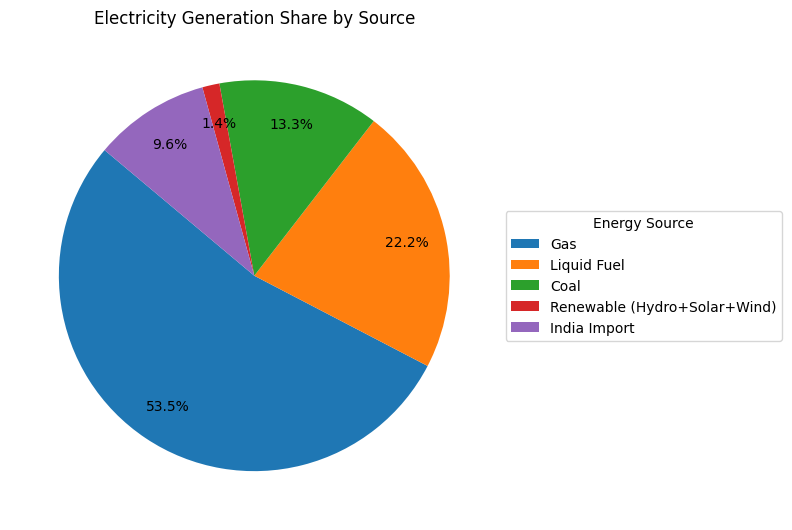

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    source_percent.values,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8
)

# legend use instead of labels on pie
plt.legend(
    wedges,
    source_percent.index,
    title="Energy Source",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Electricity Generation Share by Source")

plt.tight_layout()
plt.show()

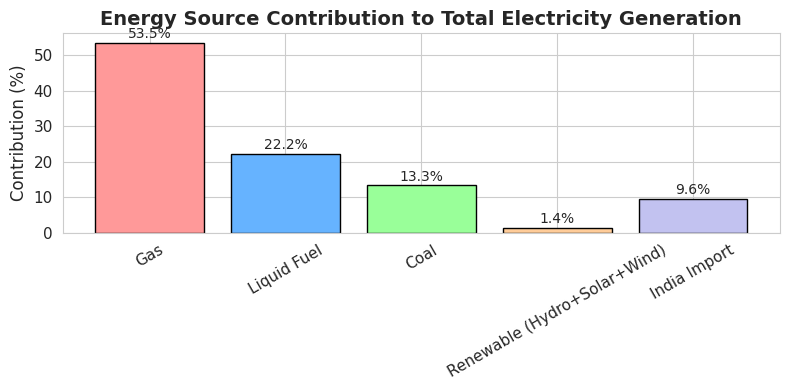

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

plt.figure(figsize=(8,4))

# Custom colors (renewable highlighted)
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0']  # Gas, Liquid, Coal, Renewable, India Import

bars = plt.bar(
    source_percent.index,
    source_percent.values,
    color=colors,
    edgecolor='black'
)

# Annotate values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,  # small gap
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Labels and title
plt.ylabel('Contribution (%)', fontsize=12)
plt.title('Energy Source Contribution to Total Electricity Generation', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

In [29]:
df.columns

Index(['hour', 'generation_mw', 'month', 'year', 'demand_mw', 'load_shedding',
       'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind',
       'india_bheramara_hvdc', 'india_bheramara_hvdc.1',
       'india_bheramara_hvdc.2', 'india_bheramara_hvdc.3', 'remarks',
       'Temperature_C', 'Humidity_%', 'Demand_lag_24hr', 'Demand_lag_168hr',
       'demand_rolling_mean_24hr', 'demand_rolling_mean_48hr',
       'demand_ema_24hr', 'temp_rolling_mean_24hr', 'coal_share'],
      dtype='object')

In [30]:
cols_to_drop = [
     'load_shedding','liquid_fuel',
    'hydro', 'solar', 'wind',
    'india_bheramara_hvdc', 'india_bheramara_hvdc.1',
    'india_bheramara_hvdc.2', 'india_bheramara_hvdc.3',
    'remarks','liquid_fuel','hydro','solar','wind','Humidity_%'
]

df.drop(columns=cols_to_drop, inplace=True)
df


,hour,generation_mw,month,year,demand_mw,gas,coal,Temperature_C,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share
datetime,,,,,,,,,,,,,,,
2018-07-19 00:00:00,0,10706.0,7,2018,10706,5578,132,27.09,NaN,NaN,NaN,NaN,10706.000000,NaN,0.012330
2018-07-19 01:00:00,1,10385.0,7,2018,10385,5543,130,26.95,NaN,NaN,NaN,NaN,10680.320000,NaN,0.012518
2018-07-19 02:00:00,2,10073.0,7,2018,10073,5567,127,26.96,NaN,NaN,NaN,NaN,10631.734400,NaN,0.012608
2018-07-19 03:00:00,3,9845.0,7,2018,9845,5723,131,27.01,NaN,NaN,NaN,NaN,10568.795648,NaN,0.013306
2018-07-19 04:00:00,4,9950.0,7,2018,9950,5678,138,26.89,NaN,NaN,NaN,NaN,10519.291996,NaN,0.013869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,11896,5678,3470,28.74,13155.0,12403.0,13804.000000,14023.041667,13479.928197,28.260000,0.291695
2025-06-17 09:00:00,9,12290.0,6,2025,12290,6065,3491,29.37,13569.0,12072.0,13750.708333,13984.437500,13384.733941,28.239583,0.284052
2025-06-17 10:00:00,10,12443.0,6,2025,12443,5900,3601,29.77,13816.0,11377.0,13693.500000,13950.562500,13309.395226,28.220417,0.289400


In [31]:
df=df.dropna()
df

,hour,generation_mw,month,year,demand_mw,gas,coal,Temperature_C,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share
datetime,,,,,,,,,,,,,,,
2018-07-25 18:00:00,18,9635.0,7,2018,9635,5538,0,28.22,9942.0,10706.0,8386.125000,8391.854167,8312.912897,28.182500,0.000000
2018-07-25 18:30:00,18,10290.0,7,2018,10290,5828,0,28.02,9873.0,10385.0,8403.500000,8396.395833,8471.079865,28.195000,0.000000
2018-07-25 19:00:00,19,10340.0,7,2018,10340,5735,0,27.82,9945.0,10073.0,8419.958333,8405.979167,8620.593476,28.207500,0.000000
2018-07-25 20:00:00,20,10303.0,7,2018,10303,5749,0,27.45,9826.0,9845.0,8439.833333,8420.000000,8755.185998,28.209583,0.000000
2018-07-25 21:00:00,21,10080.0,7,2018,10080,5715,0,27.09,9544.0,9950.0,8462.166667,8434.020833,8861.171118,28.200833,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,11896,5678,3470,28.74,13155.0,12403.0,13804.000000,14023.041667,13479.928197,28.260000,0.291695
2025-06-17 09:00:00,9,12290.0,6,2025,12290,6065,3491,29.37,13569.0,12072.0,13750.708333,13984.437500,13384.733941,28.239583,0.284052
2025-06-17 10:00:00,10,12443.0,6,2025,12443,5900,3601,29.77,13816.0,11377.0,13693.500000,13950.562500,13309.395226,28.220417,0.289400


In [32]:
df['demand_mw'].describe()


,demand_mw
count,62897.000000
mean,9829.012004
std,2665.270553
min,143.000000
25%,7981.000000
50%,9677.000000
75%,11588.000000
max,156050.000000


In [33]:
df[df['demand_mw'] > 18000]


,hour,generation_mw,month,year,demand_mw,gas,coal,Temperature_C,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share
datetime,,,,,,,,,,,,,,,
2018-12-18 08:00:00,8,5563.9,12,2018,55639,4487,149,19.590,6311.0,6627.0,8089.291667,6902.083333,9528.243767,20.091667,0.026780
2023-02-11 18:30:00,18,10052.0,2,2023,104860,4369,1594,22.145,9531.0,6980.0,12544.166667,10457.250000,16541.156105,21.995625,0.158575
2023-04-18 18:30:00,18,15172.0,4,2023,156050,6423,2197,30.810,15900.0,12911.0,20525.875000,17583.770833,25849.727575,30.694167,0.144806
2023-10-04 09:00:00,9,10587.0,10,2023,20587,5234,3221,27.290,11779.0,12650.0,12126.625000,12337.250000,12227.818002,27.321250,0.304241
2023-10-11 03:00:00,3,11468.0,10,2023,117000,6021,2965,26.300,11420.0,10439.0,16801.833333,14554.479167,21049.706911,29.248125,0.258546
2024-04-16 07:00:00,7,11701.0,4,2024,121000,6742,2979,28.270,11250.0,11416.0,17028.958333,14411.145833,20901.542475,31.497292,0.254594
2024-07-03 05:00:00,5,11080.0,7,2024,111140,5265,3774,26.700,11180.0,14200.0,16618.125000,14682.187500,20447.693050,28.504583,0.340614


In [34]:

# Single-cell: Replace outliers

# Calculate IQR (optional for analysis)
Q1 = df['demand_mw'].quantile(0.25)
Q3 = df['demand_mw'].quantile(0.75)
IQR = Q3 - Q1

# Replace extreme values without deleting rows
df['demand_mw'] = df['demand_mw'].clip(lower=3500, upper=18000)

/tmp/ipykernel_25604/165475106.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['demand_mw'] = df['demand_mw'].clip(lower=3500, upper=18000)


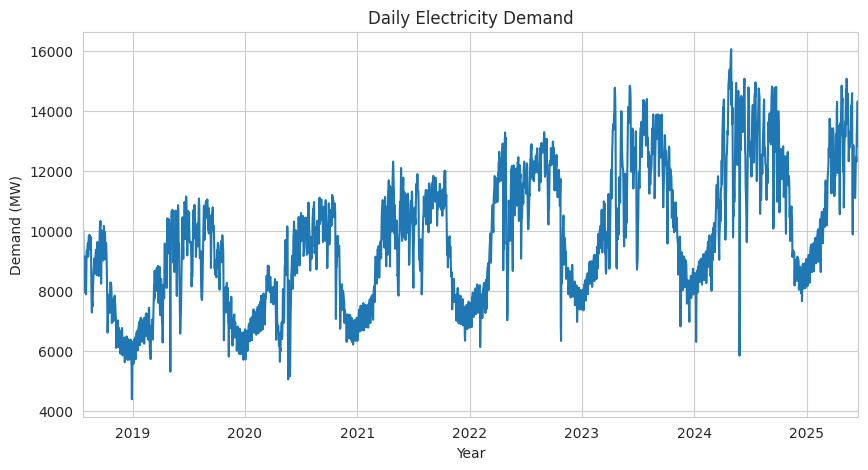

In [35]:
# Daily average demand
df_daily = df['demand_mw'].resample('D').mean().interpolate()

df_daily.plot(figsize=(10,5), title="Daily Electricity Demand")
plt.xlabel("Year")
plt.ylabel("Demand (MW)")
plt.show()


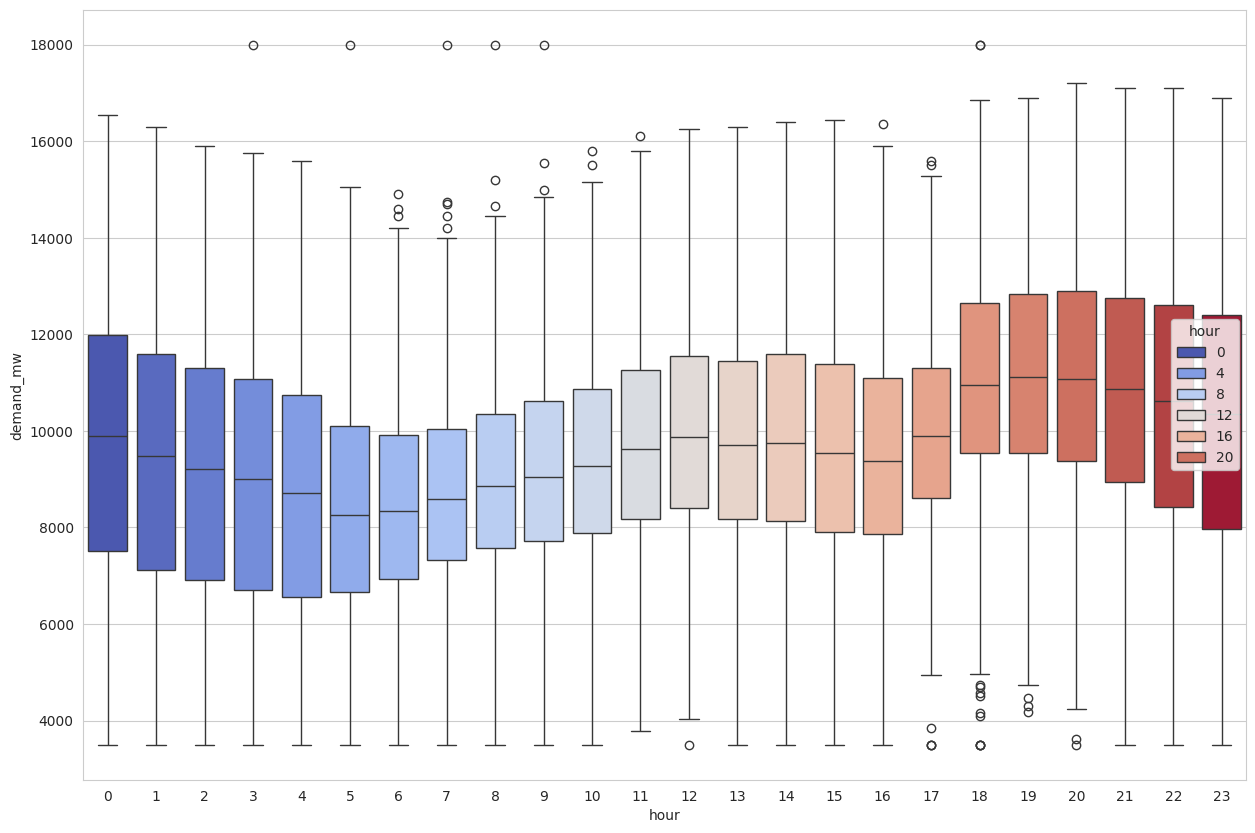

In [36]:
plt.figure(figsize=(15,10))
sns.boxplot(
    x="hour",
    y="demand_mw",
    data=df,
    palette="coolwarm",
    hue="hour",
    #showfliers=False
);


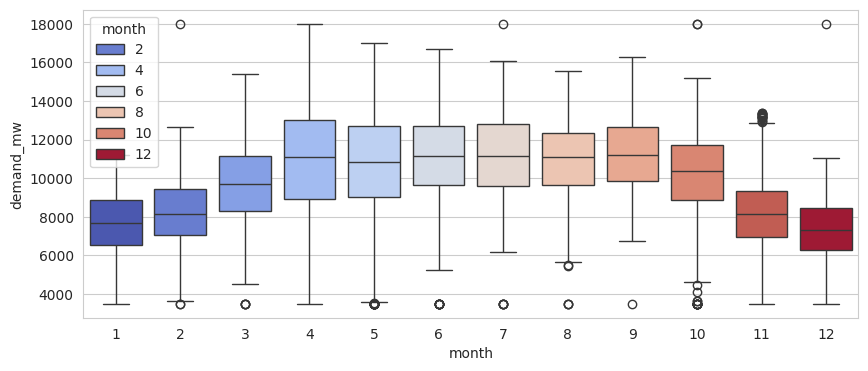

In [37]:
plt.figure(figsize=(10,4))
sns.boxplot(
    x="month",
    y="demand_mw",
    data=df,
    palette="coolwarm",
    hue="month",
    #showfliers=False
);


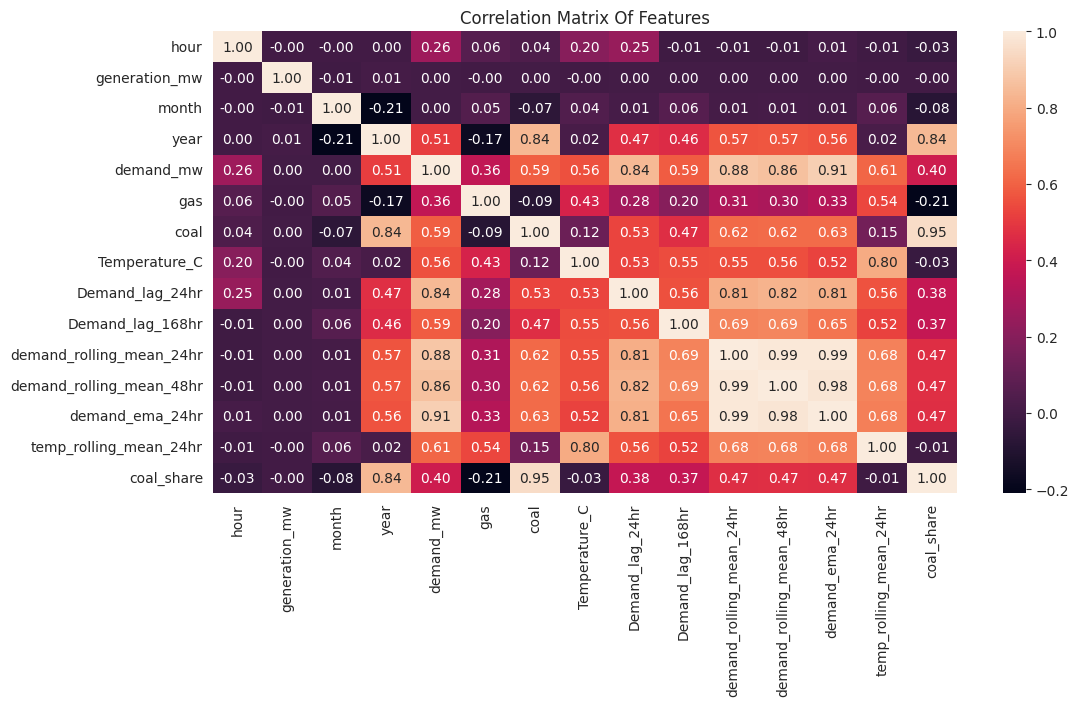

In [38]:
# correlation matrix
plt.figure(figsize=(12,6))
plt.title("Correlation Matrix Of Features")
sns.heatmap(df.corr(),annot=True,fmt=".2f");

In [39]:
#define target variable y
y=df.demand_mw # target variable/ dependent variable
print(y)

datetime
2018-07-25 18:00:00     9635
2018-07-25 18:30:00    10290
2018-07-25 19:00:00    10340
2018-07-25 20:00:00    10303
2018-07-25 21:00:00    10080
                       ...  
2025-06-17 08:00:00    11896
2025-06-17 09:00:00    12290
2025-06-17 10:00:00    12443
2025-06-17 11:00:00    12826
2025-06-17 12:00:00    13139
Name: demand_mw, Length: 62897, dtype: int64


In [40]:
#define Features(x)
x=df.drop("demand_mw",axis=1)  #indipendent variables/ features/predictors
x

,hour,generation_mw,month,year,gas,coal,Temperature_C,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share
datetime,,,,,,,,,,,,,,
2018-07-25 18:00:00,18,9635.0,7,2018,5538,0,28.22,9942.0,10706.0,8386.125000,8391.854167,8312.912897,28.182500,0.000000
2018-07-25 18:30:00,18,10290.0,7,2018,5828,0,28.02,9873.0,10385.0,8403.500000,8396.395833,8471.079865,28.195000,0.000000
2018-07-25 19:00:00,19,10340.0,7,2018,5735,0,27.82,9945.0,10073.0,8419.958333,8405.979167,8620.593476,28.207500,0.000000
2018-07-25 20:00:00,20,10303.0,7,2018,5749,0,27.45,9826.0,9845.0,8439.833333,8420.000000,8755.185998,28.209583,0.000000
2018-07-25 21:00:00,21,10080.0,7,2018,5715,0,27.09,9544.0,9950.0,8462.166667,8434.020833,8861.171118,28.200833,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,5678,3470,28.74,13155.0,12403.0,13804.000000,14023.041667,13479.928197,28.260000,0.291695
2025-06-17 09:00:00,9,12290.0,6,2025,6065,3491,29.37,13569.0,12072.0,13750.708333,13984.437500,13384.733941,28.239583,0.284052
2025-06-17 10:00:00,10,12443.0,6,2025,5900,3601,29.77,13816.0,11377.0,13693.500000,13950.562500,13309.395226,28.220417,0.289400


In [41]:
# Splitting the data into training and teating data
x_train=x.loc[ : "2024-06-29"]   #taking 80% 0f data as training data
x_train

,hour,generation_mw,month,year,gas,coal,Temperature_C,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share
datetime,,,,,,,,,,,,,,
2018-07-25 18:00:00,18,9635.0,7,2018,5538,0,28.22,9942.0,10706.0,8386.125000,8391.854167,8312.912897,28.182500,0.000000
2018-07-25 18:30:00,18,10290.0,7,2018,5828,0,28.02,9873.0,10385.0,8403.500000,8396.395833,8471.079865,28.195000,0.000000
2018-07-25 19:00:00,19,10340.0,7,2018,5735,0,27.82,9945.0,10073.0,8419.958333,8405.979167,8620.593476,28.207500,0.000000
2018-07-25 20:00:00,20,10303.0,7,2018,5749,0,27.45,9826.0,9845.0,8439.833333,8420.000000,8755.185998,28.209583,0.000000
2018-07-25 21:00:00,21,10080.0,7,2018,5715,0,27.09,9544.0,9950.0,8462.166667,8434.020833,8861.171118,28.200833,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-29 19:00:00,19,13796.0,6,2024,5658,3119,28.25,13720.0,13200.0,12585.708333,12638.375000,12528.059371,28.941458,0.226080
2024-06-29 20:00:00,20,13783.0,6,2024,5607,3122,28.10,13725.0,12753.0,12611.750000,12630.041667,12673.814621,28.962708,0.226511
2024-06-29 21:00:00,21,13740.0,6,2024,5611,3156,28.03,14100.0,12581.0,12626.333333,12624.833333,12815.909452,28.986458,0.229694


In [42]:
y_train=y.loc[ : "2024-06-29"]   #taking 80% 0f data as training data
y_train

,demand_mw
datetime,
2018-07-25 18:00:00,9635
2018-07-25 18:30:00,10290
2018-07-25 19:00:00,10340
2018-07-25 20:00:00,10303
2018-07-25 21:00:00,10080
...,...
2024-06-29 19:00:00,14000
2024-06-29 20:00:00,14350
2024-06-29 21:00:00,14450


In [43]:
y_test=y.loc[ "2024-06-30": ]   #taking 20% 0f data as testing data
y_test

,demand_mw
datetime,
2024-06-30 00:00:00,14150
2024-06-30 01:00:00,13800
2024-06-30 02:00:00,13700
2024-06-30 03:00:00,13550
2024-06-30 04:00:00,13300
...,...
2025-06-17 08:00:00,11896
2025-06-17 09:00:00,12290
2025-06-17 10:00:00,12443


In [44]:
x_test=x.loc[ "2024-06-30": ]   #taking 20% 0f data as testing data
x_test

,hour,generation_mw,month,year,gas,coal,Temperature_C,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share
datetime,,,,,,,,,,,,,,
2024-06-30 00:00:00,0,12775.0,6,2024,5616,3058,27.96,13850.0,11393.0,12682.583333,12635.250000,13178.135699,29.058958,0.239374
2024-06-30 01:00:00,1,12712.0,6,2024,5662,3045,28.01,13450.0,12019.0,12697.166667,12632.125000,13227.884843,29.083958,0.239537
2024-06-30 02:00:00,2,12681.0,6,2024,5739,3056,27.98,13200.0,12303.0,12718.000000,12633.166667,13265.654056,29.105208,0.240990
2024-06-30 03:00:00,3,12540.0,6,2024,5670,3042,27.80,13000.0,12441.0,12740.916667,12649.833333,13288.401731,29.120208,0.242584
2024-06-30 04:00:00,4,12461.0,6,2024,5616,3049,27.63,12100.0,12719.0,12790.916667,12675.875000,13289.329593,29.126042,0.244683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,5678,3470,28.74,13155.0,12403.0,13804.000000,14023.041667,13479.928197,28.260000,0.291695
2025-06-17 09:00:00,9,12290.0,6,2025,6065,3491,29.37,13569.0,12072.0,13750.708333,13984.437500,13384.733941,28.239583,0.284052
2025-06-17 10:00:00,10,12443.0,6,2025,5900,3601,29.77,13816.0,11377.0,13693.500000,13950.562500,13309.395226,28.220417,0.289400


In [45]:
print(x_train.shape)
print(y_train.shape)

(54086, 14)
(54086,)


In [46]:
print(x_test.shape)
print(y_test.shape)

(8811, 14)
(8811,)


#Decision Tree

In [47]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
dt_model=DecisionTreeRegressor(max_depth=6,
                               min_samples_split=20,
                               min_samples_leaf=10,
                               criterion="squared_error",
                               random_state=42)
dt_model.fit(x_train,y_train)
dt_pred=dt_model.predict(x_test)
rmse_dt=np.sqrt(mean_squared_error(y_test,dt_pred))
mae_dt=mean_absolute_error(y_test,dt_pred)

print("Decision Tree RMSE: ",rmse_dt)
print("Decision Tree MAE ",mae_dt)

Decision Tree RMSE:  417.7885947100062
Decision Tree MAE  233.41657297688693


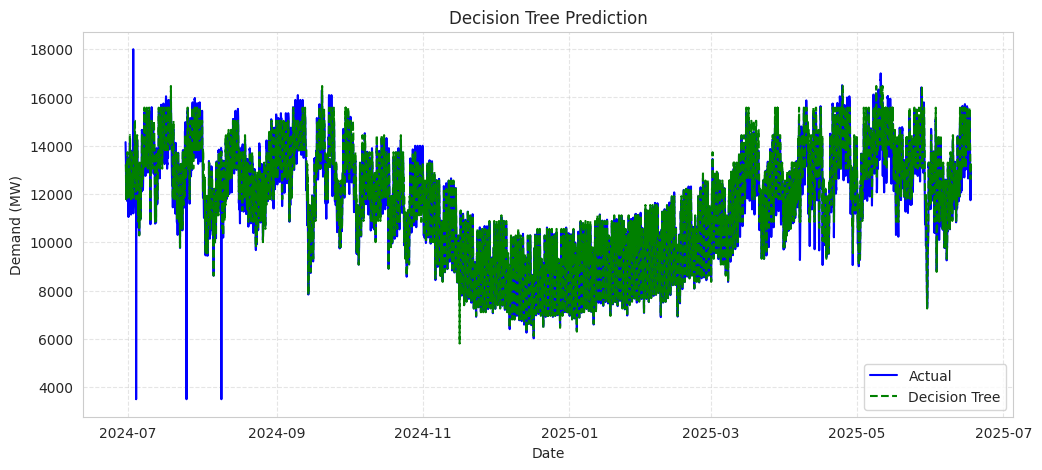

In [48]:
# Decision Tree prediction plot
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Actual', color='blue')           # Real demand
plt.plot(y_test.index, dt_pred, label='Decision Tree', color='green', linestyle='--')  # Predicted by Decision Tree
plt.title("Decision Tree Prediction")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


#Random Forest

In [49]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
rf_model=RandomForestRegressor(n_estimators=200,
                               max_depth=8,
                               min_samples_split=5,
                               min_samples_leaf=2,
                               random_state=42)
rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
mae_rf = mean_absolute_error(y_test, rf_pred)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 351.8985979429464
Random Forest MAE: 197.65745484647437


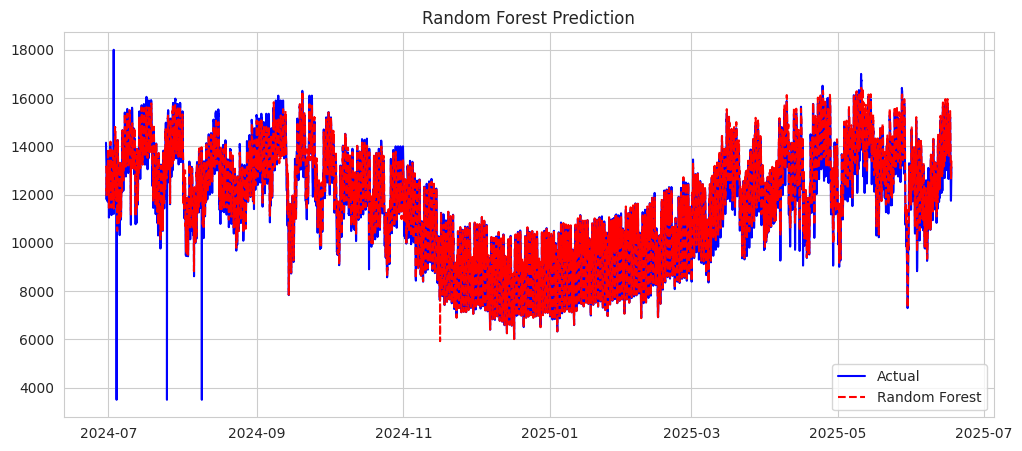

In [50]:

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Actual', color='blue')
plt.plot(y_test.index, rf_pred, label='Random Forest', color='red', linestyle='--')
plt.title("Random Forest Prediction")
plt.legend()
plt.show()


#XGBoost

In [51]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

In [52]:
model_xgb=XGBRegressor(n_estimators=2500,
                       early_stopping_rounds=50,
                       learning_rate=0.005,
                       max_depth=7,
                       min_child_weight=3,
                       gamma=1,
                       subsample=0.8,
                       reg_alpha=0.1,
                       reg_lambda=1.5,
                       random_state=42,
                       objective="reg:squarederror")

In [53]:
model_xgb.fit(x_train,y_train,eval_set=[(x_train,y_train),(x_test,y_test)],verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.005, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2500,
             n_jobs=None, num_parallel_tree=None, ...)

In [54]:
predictions_xgb=model_xgb.predict(x_test)
rmse_xgb=np.sqrt(mean_squared_error(y_test,predictions_xgb))
mae_xgb=mean_absolute_error(y_test,predictions_xgb)
print("XGBoost RMSE:",rmse_xgb)
print("XGBoost MAE:",mae_xgb)

XGBoost RMSE: 327.9136700413693
XGBoost MAE: 182.6034393310547


Text(65.72222222222221, 0.5, 'Demand')

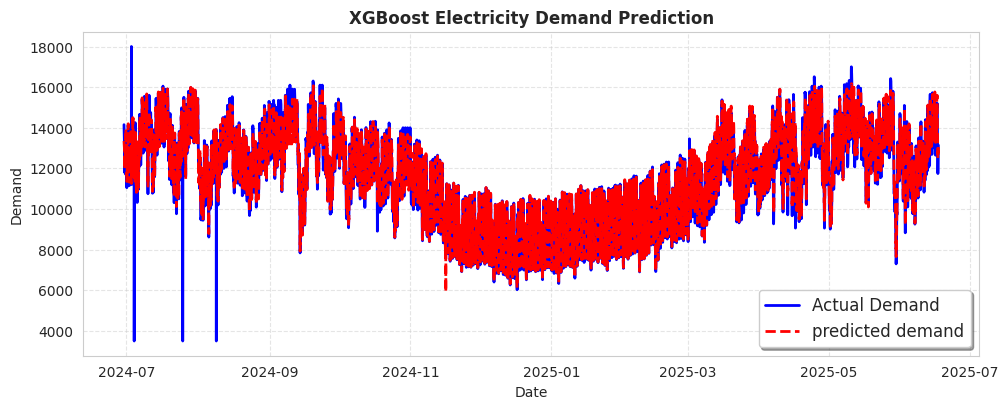

In [55]:
plt.figure(figsize=(10,4))
plt.plot(y_test.index,y_test,label="Actual Demand",color="Blue", linewidth=2)
plt.plot(y_test.index,predictions_xgb,label="predicted demand",color='Red',linestyle="--", linewidth=2)
plt.title("XGBoost Electricity Demand Prediction",fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend(fontsize=12, shadow=True)

plt.xlabel("Date")
plt.ylabel("Demand")

In [56]:
from sklearn.metrics import r2_score
r2_dt=r2_score(y_test,dt_pred)
r2_rf=r2_score(y_test,rf_pred)
r2_xgb=r2_score(y_test,predictions_xgb)

print("Decision Tree R2: ",r2_dt)
print("Random Forest R2:",r2_rf)
print("XGBoost R2: ",r2_xgb)




Decision Tree R2:  0.9640858240533939
Random Forest R2: 0.9745206808281283
XGBoost R2:  0.9778755903244019


ANN

Scaling (MinMax)

In [57]:
from sklearn.preprocessing import MinMaxScaler

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

x_train_scaled = scaler_x.fit_transform(x_train)
x_test_scaled = scaler_x.transform(x_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

Tensor Convert

In [58]:
import torch

x_train_t = torch.tensor(x_train_scaled, dtype=torch.float32)
x_test_t = torch.tensor(x_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

In [59]:
import torch.nn as nn
import torch.optim as optim

class ResearchANN(nn.Module):
    def __init__(self, input_size):
        super(ResearchANN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

Initialize Model

In [60]:
input_size = x_train_t.shape[1]

model = ResearchANN(input_size)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

Training with Loss Tracking

In [61]:
epochs = 50

train_losses = []

for epoch in range(epochs):

    model.train()

    outputs = model(x_train_t)
    loss = criterion(outputs, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch+1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {loss.item():.6f}")

Epoch [25/50] Loss: 0.014100
Epoch [50/50] Loss: 0.009515


Evaluation  (RMSE + MAE + MAPE + R²)

In [62]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

model.eval()

with torch.no_grad():
    predictions = model(x_test_t)

# Back to original scale
predictions = scaler_y.inverse_transform(predictions.numpy())
y_test_actual = scaler_y.inverse_transform(y_test_t.numpy())

# Metrics
rmse_ann = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae_ann = mean_absolute_error(y_test_actual, predictions)

# MAPE (manual calculation)
mape_ann = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

r2_ann = r2_score(y_test_actual, predictions)

print("Research ANN RMSE:", rmse_ann)
print("Research ANN MAE:", mae_ann)
print("Research ANN MAPE:", mape_ann)
print("Research ANN R2:", r2_ann)

Research ANN RMSE: 1709.1925725324224
Research ANN MAE: 1428.6341552734375
Research ANN MAPE: 11.6693125
Research ANN R2: 0.3989166021347046


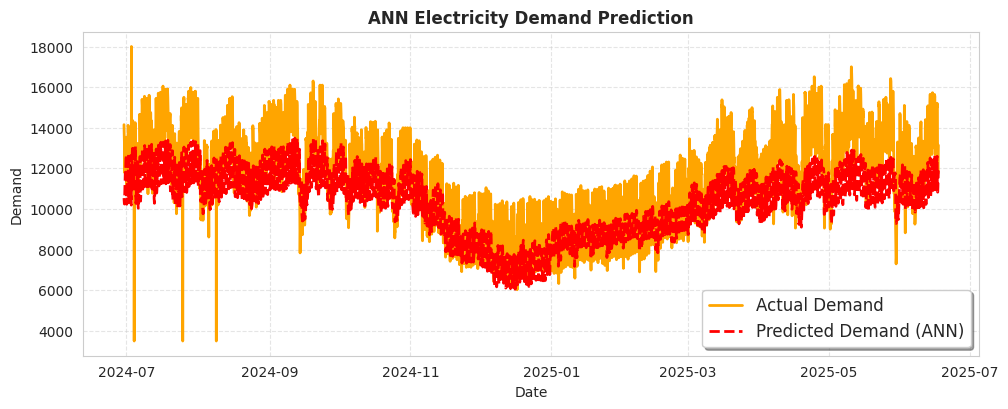

In [63]:
plt.figure(figsize=(10,4))

plt.plot(y_test.index, y_test_actual.flatten(),
         label="Actual Demand",
         color="Orange",
         linewidth=2)

plt.plot(y_test.index, predictions.flatten(),
         label="Predicted Demand (ANN)",
         color="Red",
         linestyle="--",
         linewidth=2)

plt.title("ANN Electricity Demand Prediction", fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend(fontsize=12, shadow=True)

plt.xlabel("Date")
plt.ylabel("Demand")

plt.show()

#CNN

In [64]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import gc
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
torch.backends.cudnn.benchmark = True

Device: cuda


In [65]:
import numpy as np

def create_sequences(X, y, seq_length=168):
    X_seq, y_seq = [], []

    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])

    return np.array(X_seq), np.array(y_seq)

seq_length = 168

X_train_seq, y_train_seq = create_sequences(x_train_scaled, y_train_scaled, seq_length)
X_test_seq, y_test_seq   = create_sequences(x_test_scaled, y_test_scaled, seq_length)

print("Train:", X_train_seq.shape, y_train_seq.shape)
print("Test :", X_test_seq.shape, y_test_seq.shape)

Train: (53918, 168, 14) (53918, 1)
Test : (8643, 168, 14) (8643, 1)


In [66]:
import torch

X_train_seq = torch.tensor(X_train_seq, dtype=torch.float32)
X_test_seq  = torch.tensor(X_test_seq, dtype=torch.float32)

y_train_seq = torch.tensor(y_train_seq, dtype=torch.float32)
y_test_seq  = torch.tensor(y_test_seq, dtype=torch.float32)

print(" Converted to Tensor")

 Converted to Tensor


In [67]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 128

train_dataset = TensorDataset(X_train_seq, y_train_seq)
test_dataset  = TensorDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

print(" DataLoader Ready")

 DataLoader Ready


In [68]:
import torch.nn as nn

class CNN_Model(nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.conv1 = nn.Conv1d(num_features, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 32, kernel_size=3, padding=1)

        self.pool = nn.MaxPool1d(2)
        self.bn = nn.BatchNorm1d(32)
        self.dropout = nn.Dropout(0.2)

        self.fc1 = nn.Linear(32, 32)
        self.fc2 = nn.Linear(32, 1)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.permute(0,2,1)

        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))

        x = self.pool(x)
        x = self.bn(x)
        x = self.dropout(x)

        x = torch.mean(x, dim=2)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

model = CNN_Model(X_train_seq.shape[2]).to(device)

print("Model Ready")

Model Ready


In [69]:
import time
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

num_epochs = 50
patience = 5

best_loss = float('inf')
trigger = 0
loss_history = []

model.train()
start = time.time()

for epoch in range(num_epochs):
    epoch_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()*xb.size(0)

    epoch_loss /= len(train_loader.dataset)
    loss_history.append(epoch_loss)

    print(f"Epoch {epoch+1}: {epoch_loss:.6f}")

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        trigger = 0
        torch.save(model.state_dict(), "best_cnn.pt")
    else:
        trigger += 1
        if trigger >= patience:
            print(" Early Stopping")
            break

print("Time (min):", (time.time()-start)/60)

Epoch 1: 0.011295
Epoch 2: 0.005187
Epoch 3: 0.004064
Epoch 4: 0.003686
Epoch 5: 0.003404
Epoch 6: 0.003259
Epoch 7: 0.003102
Epoch 8: 0.002980
Epoch 9: 0.002766
Epoch 10: 0.002510
Epoch 11: 0.002306
Epoch 12: 0.002219
Epoch 13: 0.002118
Epoch 14: 0.002113
Epoch 15: 0.001979
Epoch 16: 0.001958
Epoch 17: 0.001927
Epoch 18: 0.001861
Epoch 19: 0.001855
Epoch 20: 0.001760
Epoch 21: 0.001748
Epoch 22: 0.001779
Epoch 23: 0.001748
Epoch 24: 0.001664
Epoch 25: 0.001641
Epoch 26: 0.001623
Epoch 27: 0.001586
Epoch 28: 0.001580
Epoch 29: 0.001585
Epoch 30: 0.001551
Epoch 31: 0.001484
Epoch 32: 0.001494
Epoch 33: 0.001455
Epoch 34: 0.001464
Epoch 35: 0.001480
Epoch 36: 0.001442
Epoch 37: 0.001437
Epoch 38: 0.001421
Epoch 39: 0.001415
Epoch 40: 0.001352
Epoch 41: 0.001387
Epoch 42: 0.001334
Epoch 43: 0.001373
Epoch 44: 0.001384
Epoch 45: 0.001329
Epoch 46: 0.001340
Epoch 47: 0.001326
Epoch 48: 0.001306
Epoch 49: 0.001353
Epoch 50: 0.001288
Time (min): 1.3040102203687032


In [74]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model.load_state_dict(torch.load("best_cnn.pt"))
model.eval()

preds = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = model(xb)
        preds.append(out.cpu().numpy())

y_pred = np.concatenate(preds, axis=0)

# Inverse scaling
y_pred_inv = scaler_y.inverse_transform(y_pred)
y_test_inv = scaler_y.inverse_transform(y_test_seq.numpy())

mse  = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_inv, y_pred_inv)
r2   = r2_score(y_test_inv, y_pred_inv)
mape = np.mean(np.abs((y_test_inv - y_pred_inv)/y_test_inv))*100

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)
print("R2  :", r2)

MSE : 403700.0625
RMSE: 635.3739548486387
MAE : 505.9417419433594
MAPE: 4.7351627
R2  : 0.9177811741828918


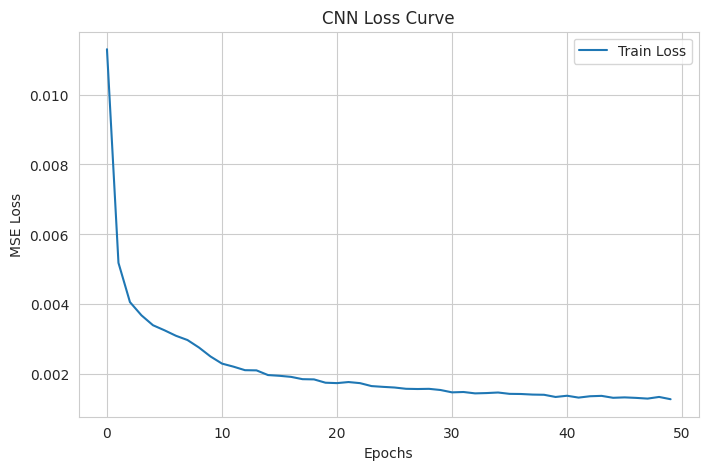

In [71]:
plt.figure(figsize=(8,5))
plt.plot(loss_history,label="Train Loss")
plt.xlabel("Epochs"); plt.ylabel("MSE Loss")
plt.title("CNN Loss Curve")
plt.legend()
plt.show()

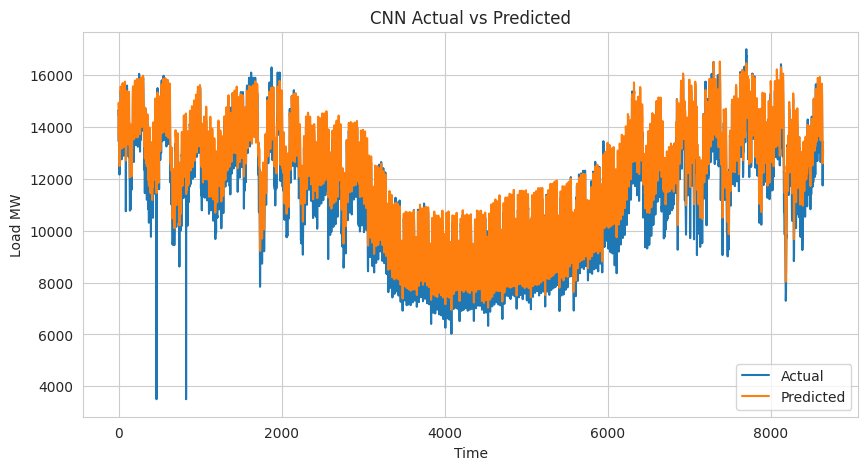

In [72]:
plt.figure(figsize=(10,5))
plt.plot(y_test_inv,label="Actual")
plt.plot(y_pred_inv,label="Predicted")
plt.xlabel("Time")
plt.ylabel("Load MW")
plt.title("CNN Actual vs Predicted")
plt.legend()
plt.show()

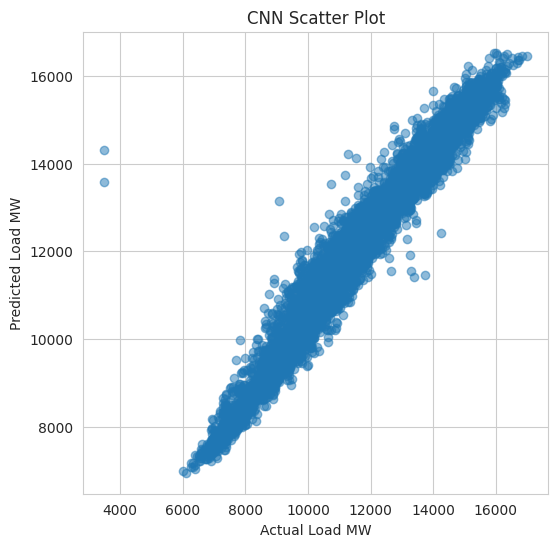

In [73]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_inv, y_pred_inv, alpha=0.5)
plt.xlabel("Actual Load MW")
plt.ylabel("Predicted Load MW")
plt.title("CNN Scatter Plot")
plt.show()